In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import pickle

df = pd.read_csv("FLAT_GGN_FINAL_FIXED_MEDIAN.csv")
df = df.drop(columns=["areaWithType",'price_per_sqft',"luxury_score","sector_number"])




In [3]:
X = df.drop("price",axis=1)
y = df["price"]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size= 0.2,
    random_state= 42
)

model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE:", mae)

r2 = r2_score(
    y_test,
    y_pred
)

print("R2 Score:", r2)


with open("house_price_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model Saved!")

with open("columns.pkl", "wb") as file:
    pickle.dump(X.columns.tolist(), file)

print("Model and columns saved successfully!")

MAE: 0.5802238791366787
R2 Score: 0.8036396448837516
Model Saved!
Model and columns saved successfully!


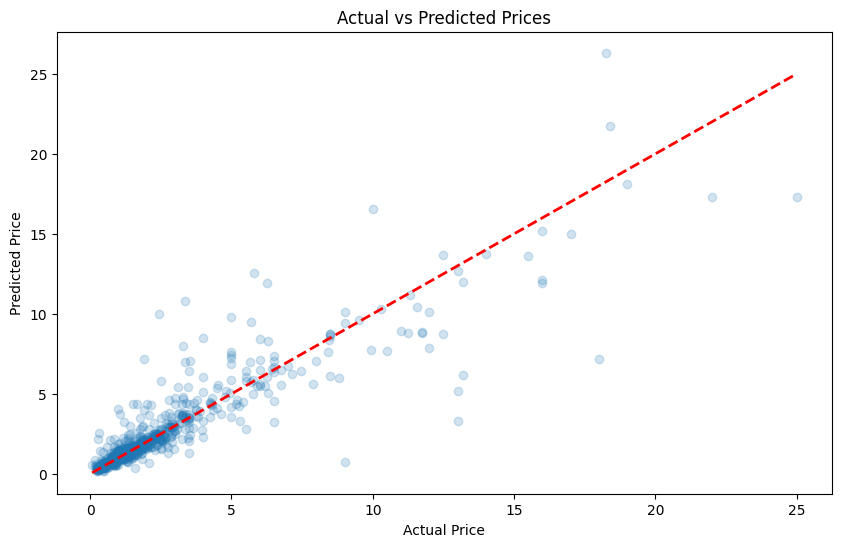

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(y_test, y_pred, alpha=0.2)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()